In [ ]:
# Instalar librerías necesarias
!pip install scikit-learn pandas matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("✅ Librerías listas")

✅ Librerías listas


In [ ]:
# Cargamos el dataset directamente desde URL (sin necesidad de Kaggle)
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

df = pd.read_csv(url)
print("✅ Dataset cargado")
print(df.shape)
df.head()

✅ Dataset cargado
(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


/tmp/ipykernel_3372/3062719974.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='Set2')


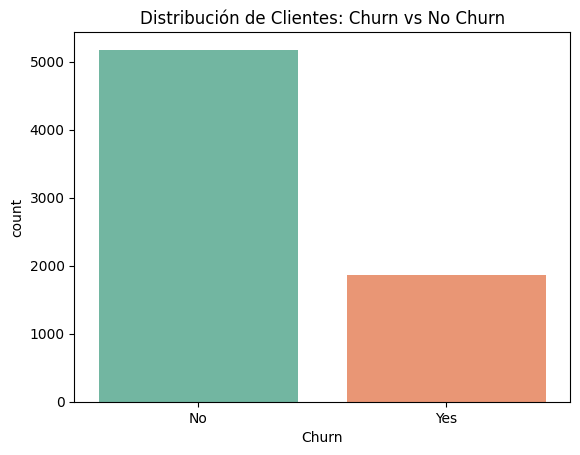

In [ ]:
# Ver información general
print(df.info())
print("\n")
print(df['Churn'].value_counts())

# Visualizar distribución de abandono
sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Distribución de Clientes: Churn vs No Churn')
plt.show()

In [ ]:
# Convertir TotalCharges a numérico
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Eliminar filas con valores nulos
df.dropna(inplace=True)

# Eliminar columna ID (no aporta al modelo)
df.drop('customerID', axis=1, inplace=True)

print("✅ Datos limpios")
print(df.shape)

✅ Datos limpios
(7032, 20)


In [ ]:
# Convertir columnas de texto a números
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

print("✅ Variables codificadas")
df.head()

✅ Variables codificadas


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [ ]:
# Separar características (X) y variable objetivo (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# Dividir en 80% entrenamiento / 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"✅ Entrenamiento: {X_train.shape[0]} filas")
print(f"✅ Prueba: {X_test.shape[0]} filas")

✅ Entrenamiento: 5625 filas
✅ Prueba: 1407 filas


In [ ]:
modelo_lr = LogisticRegression(max_iter=1000)
modelo_lr.fit(X_train, y_train)

pred_lr = modelo_lr.predict(X_test)

print("📊 REGRESIÓN LOGÍSTICA")
print(f"Accuracy: {accuracy_score(y_test, pred_lr):.2%}")
print(classification_report(y_test, pred_lr))

📊 REGRESIÓN LOGÍSTICA
Accuracy: 78.54%
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)

pred_rf = modelo_rf.predict(X_test)

print("📊 RANDOM FOREST")
print(f"Accuracy: {accuracy_score(y_test, pred_rf):.2%}")
print(classification_report(y_test, pred_rf))

📊 RANDOM FOREST
Accuracy: 79.25%
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.49      0.56       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



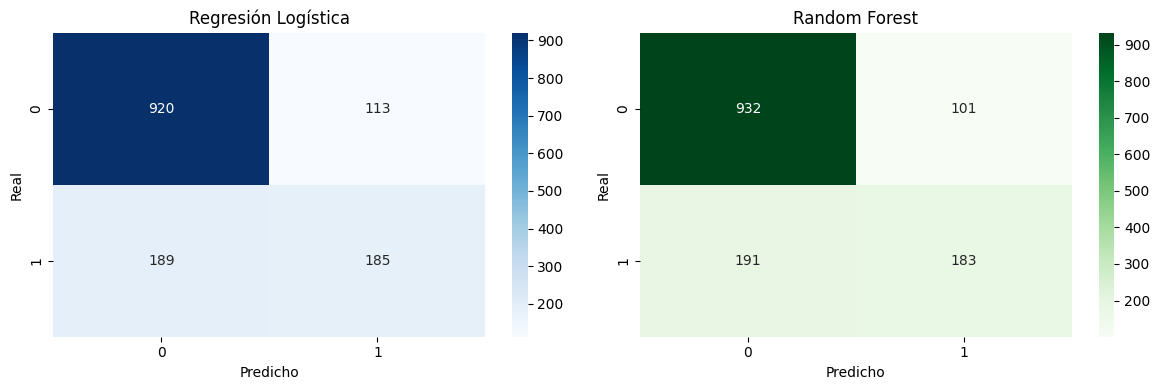

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Matriz Regresión Logística
sns.heatmap(confusion_matrix(y_test, pred_lr),
            annot=True, fmt='d', ax=axes[0],
            cmap='Blues')
axes[0].set_title('Regresión Logística')
axes[0].set_xlabel('Predicho')
axes[0].set_ylabel('Real')

# Matriz Random Forest
sns.heatmap(confusion_matrix(y_test, pred_rf),
            annot=True, fmt='d', ax=axes[1],
            cmap='Greens')
axes[1].set_title('Random Forest')
axes[1].set_xlabel('Predicho')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()

/tmp/ipykernel_3372/2038221928.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importancias.values, y=importancias.index, palette='viridis')


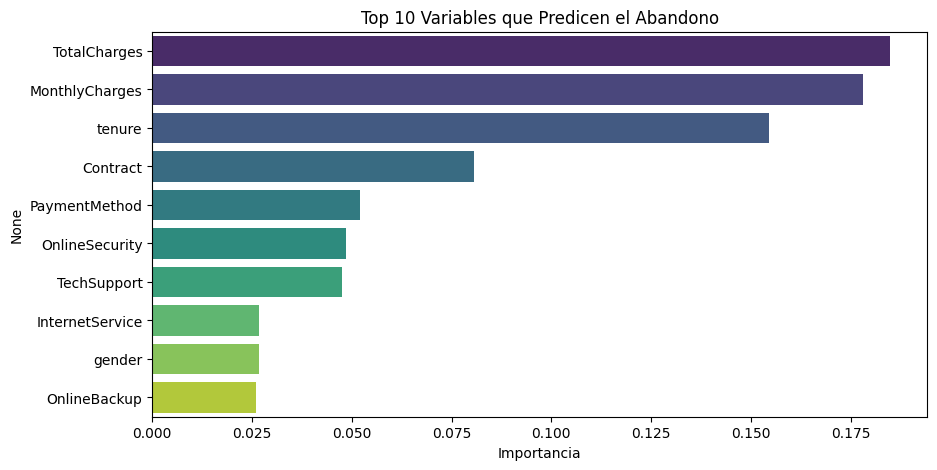

In [ ]:
importancias = pd.Series(
    modelo_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=importancias.values, y=importancias.index, palette='viridis')
plt.title('Top 10 Variables que Predicen el Abandono')
plt.xlabel('Importancia')
plt.show()

In [ ]:
print("=" * 50)
print("RESUMEN DEL PROYECTO")
print("=" * 50)
print(f"Regresión Logística - Accuracy: {accuracy_score(y_test, pred_lr):.2%}")
print(f"Random Forest       - Accuracy: {accuracy_score(y_test, pred_rf):.2%}")
print()
print("Variable más importante para predecir abandono:")
print(f"👉 {importancias.index[0]}")
print()
print("Conclusión: El modelo Random Forest es más preciso")
print("para identificar clientes en riesgo de abandonar.")

RESUMEN DEL PROYECTO
Regresión Logística - Accuracy: 78.54%
Random Forest       - Accuracy: 79.25%

Variable más importante para predecir abandono:
👉 TotalCharges

Conclusión: El modelo Random Forest es más preciso
para identificar clientes en riesgo de abandonar.
